# Code for processing and clustering of D16 data

last updated: 20241125

In [1]:
import scanpy as sc
import pandas as pd
import anndata
import os
import re
import numpy as np
import scipy
import seaborn
import bbknn
import matplotlib
import matplotlib.pyplot as plt


/Users/saranolbrant/opt/anaconda3/envs/scanpy-cluster/lib/python3.9/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Set a path to your working directory and results file
directory='/Set/your/path/'
# Save .ha5ad with data before QC filtering
Meta_data_file=directory+'/Written_files/D16_GEX_pre-QC.h5ad'
# Save .ha5ad with data after QC filtering and clustering
Results_file=directory+'/Written_files/D16_GEX_processed-clustered.h5ad'

In [3]:
# List all files
fileListAll=os.listdir(directory)

# Select files of interest
namesOfInterest=['D16']

fileList=[]
# for d in directory:    #add this if concatenating files from different directories
for f in fileListAll:
    if os.path.exists(os.path.join(directory,f,'outs','filtered_feature_bc_matrix.h5')):
        if any([ n in f for n in namesOfInterest]):
            fileList.append(os.path.join(f))  # (d,f) if you want the directory added
            
#print(fileList) 

adatas=[]   
for f in fileList:
    #print(f)
    adata = sc.read_10x_h5(os.path.join(directory,f,'outs','filtered_feature_bc_matrix.h5'))
    adata.uns['name']=f
    #print (adata.uns)
    adata.obs['batch_name']=str(adata.uns['name'])
    #print (adata.obs)
    adata.obs_names_make_unique()
    adata.var_names_make_unique()
    adatas.append(adata)

print (adatas)

/Users/saranolbrant/opt/anaconda3/envs/scanpy-cluster/lib/python3.9/site-packages/anndata/_core/anndata.py:1830: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/Users/saranolbrant/opt/anaconda3/envs/scanpy-cluster/lib/python3.9/site-packages/anndata/_core/anndata.py:1830: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/Users/saranolbrant/opt/anaconda3/envs/scanpy-cluster/lib/python3.9/site-packages/anndata/_core/anndata.py:1830: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/Users/saranolbrant/opt/anaconda3/envs/scanpy-cluster/lib/python3.9/site-packages/anndata/_core/anndata.py:1830: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/Users/saranolbr

[AnnData object with n_obs × n_vars = 3266 × 61977
    obs: 'batch_name'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'name', AnnData object with n_obs × n_vars = 11674 × 62260
    obs: 'batch_name'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'name', AnnData object with n_obs × n_vars = 11633 × 36601
    obs: 'batch_name'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'name', AnnData object with n_obs × n_vars = 199 × 66388
    obs: 'batch_name'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'name', AnnData object with n_obs × n_vars = 1777 × 62260
    obs: 'batch_name'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'name', AnnData object with n_obs × n_vars = 6951 × 62260
    obs: 'batch_name'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'name', AnnData object with n_obs × n_vars = 6534 × 62260
    obs: 'batch_name'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'name', AnnData object with n_obs × n_vars = 458 × 619

In [4]:
# Concatenate data along the observations axis.
adata=anndata.AnnData.concatenate(*adatas, join='outer', batch_categories=fileList) 

/Users/saranolbrant/opt/anaconda3/envs/scanpy-cluster/lib/python3.9/site-packages/anndata/_core/anndata.py:1785: FutureWarning: X.dtype being converted to np.float32 from float64. In the next version of anndata (0.9) conversion will not be automatic. Pass dtype explicitly to avoid this warning. Pass `AnnData(X, dtype=X.dtype, ...)` to get the future behavour.
  [AnnData(sparse.csr_matrix(a.shape), obs=a.obs) for a in all_adatas],


## Adding CHIR99021 concentration (MULTIseq label) as an observation

In [5]:
# Store all multiseq data frames
multiseq_csvs = []

for dirname in fileList:
    if os.path.exists('{}/outs/multiseq_calls.csv'.format(dirname)):
        ms = pd.read_csv('{}/outs/multiseq_calls.csv'.format(dirname), sep=',', index_col=0)
        # Append directory name to barcode so it matches adata later
        ms.index += '-' + dirname
        multiseq_csvs.append(ms)

multiseq_metadata = pd.concat(multiseq_csvs, axis=0)

# Add multiseq metadata to adata.obs
adata.obs = adata.obs.merge(multiseq_metadata, left_index=True, right_index=True, how='left')
adata.obs = adata.obs.drop(['batch'], axis=1)

# Load CHIR data csv
chir_meta = pd.read_csv('Cell_batches_CHIR-conc.csv')
chir_meta = chir_meta.loc[chir_meta['method'] != 'MULTIseq']
chir_meta.drop(['CHIR_conc', 'method'], axis=1, inplace=True)

# Store barcode in a column since it will be lost when merging
adata.obs['bc'] = adata.obs.index
# Merge with CHIR metadata
adata.obs = adata.obs.merge(chir_meta, left_on='batch_name', right_on='batch_name', how='left')
# Replace weird integer index with barcodes and drop barcode column
adata.obs = adata.obs.set_index(adata.obs['bc'])
adata.obs = adata.obs.drop(['bc'], axis=1)
# Drop index name
adata.obs.index.name = None

# Create a new column for CHIR concentration
adata.obs['CHIR_conc'] = np.nan
# Pull CHIR concentration from rows where we knew it from batch name
adata.obs.loc[~adata.obs['CHIR'].isna(), 'CHIR_conc'] = adata.obs.loc[~adata.obs['CHIR'].isna(), :]['CHIR']
# Pull CHIR concentration from multiseq column where applicable
adata.obs.loc[~adata.obs['assignment'].isna(), 'CHIR_conc'] = adata.obs.loc[~adata.obs['assignment'].isna(), :]['assignment']
# Drop temporary CHIR column
adata.obs = adata.obs.drop(['CHIR'], axis=1)

print(adata.obs)

                                                               batch_name  \
AAACAGCCATAATTGC-1-D16_outgroup-exp_Orangutan  D16_outgroup-exp_Orangutan   
AAACATGCACCTGCTC-1-D16_outgroup-exp_Orangutan  D16_outgroup-exp_Orangutan   
AAACATGCAGAAACGT-1-D16_outgroup-exp_Orangutan  D16_outgroup-exp_Orangutan   
AAACCAACAAGTGAAC-1-D16_outgroup-exp_Orangutan  D16_outgroup-exp_Orangutan   
AAACCAACAGGGAGCT-1-D16_outgroup-exp_Orangutan  D16_outgroup-exp_Orangutan   
...                                                                   ...   
TTTGTTGGTCTATCGT-1-D16_M_Chimp                                D16_M_Chimp   
TTTGTTGGTTAGTACG-1-D16_M_Chimp                                D16_M_Chimp   
TTTGTTGGTTCCTGAT-1-D16_M_Chimp                                D16_M_Chimp   
TTTGTTGGTTGGTTAG-1-D16_M_Chimp                                D16_M_Chimp   
TTTGTTGGTTGTGATG-1-D16_M_Chimp                                D16_M_Chimp   

                                              demux_type assignment CHIR_co

/Users/saranolbrant/opt/anaconda3/envs/scanpy-cluster/lib/python3.9/site-packages/anndata/_core/anndata.py:798: UserWarning: 
AnnData expects .obs.index to contain strings, but got values like:
    [0, 1, 2, 3, 4]

    Inferred to be: integer

  value_idx = self._prep_dim_index(value.index, attr)


## Adding individual identity as an observation

In [6]:
# Load all 3 files for indivudal demultiplexing as data frames
assn_Human = pd.read_csv('Human_all.assignments2', sep='\t', index_col=0, names=['individual', 'individual_type', 'individual_llr'])
assn_Chimp = pd.read_csv('Chimp_all.assignments2', sep='\t', index_col=0, names=['individual', 'individual_type', 'individual_llr'])
assn_Rhesus = pd.read_csv('Rhesus_all.assignments4', sep='\t', index_col=0, names=['individual', 'individual_type', 'individual_llr'])
# Combine them into a single data frame
assn_all = pd.concat([assn_Human, assn_Chimp, assn_Rhesus], axis=0)
# Merge the combined data with anndata
adata.obs = adata.obs.merge(assn_all, how='left', left_index=True, right_index=True)

## Adding species as an observation

In [7]:
adata.obs['species'] = 'human'
chimp = adata.obs['batch_name'].str.contains('himp')
adata.obs.loc[chimp, 'species'] = 'chimp'
macaque = adata.obs['batch_name'].str.contains('hesus')
adata.obs.loc[macaque, 'species'] = 'macaque'
orangutan = adata.obs['batch_name'].str.contains('rangutan')
adata.obs.loc[orangutan, 'species'] = 'orangutan'

In [8]:
adata.obs['species'].value_counts()

chimp        52916
human        38098
macaque       7122
orangutan     4025
Name: species, dtype: int64

In [10]:
# Rename macaque and orangutan individuals
adata.obs.loc[adata.obs['species'] == 'orangutan', 'individual'] = 'O11045-4593'
adata.obs.loc[adata.obs['individual'] == 'Rhesus_2', 'individual'] = 'ZH26-HS16'
adata.obs.loc[adata.obs['individual'] == 'Rhesus_0', 'individual'] = 'ZG15-M11-10'

In [11]:
adata.obs['individual'].value_counts()

C8861            9208
C4933            7852
C3651            7542
H20961           7353
H29089           5317
                 ... 
H21792+H23555      88
H23555+H9          80
H23555+H28834      80
H28834+H9          74
H21792+H28834      67
Name: individual, Length: 71, dtype: int64

## Adding pool type as an observation

In [12]:
adata.obs['batch_name'].value_counts()

D16_M_Chimp                   14280
D16_M0_5_Chimp                11700
D16_CH_Chimp                  11674
D16_M_Human                   11633
D16_CH_Human                  11305
D16_CH2_Chimp                  6951
D16_CH2_Human                  6816
D16_outgroup-exp_Rhesus        6731
D16_M2_Chimp                   6534
D16_M2_Human                   5246
D16_outgroup-exp_Orangutan     3266
D16_outgroup-exp_Chimp         1777
D16_M0_5_Human                 1666
D16_outgroup-exp_Human         1432
D16_M_Orangutan                 458
D16_M0_5_Rhesus                 199
D16_M2_Orangutan                193
D16_M_Rhesus                    124
D16_M0_5_Orangutan              108
D16_M2_Rhesus                    68
Name: batch_name, dtype: int64

In [13]:
adata.obs['pool_type'] = 'Interspecies'
Intraspecies = adata.obs['batch_name'].str.contains('_CH|outgroup-exp')
adata.obs.loc[Intraspecies, 'pool_type'] = 'Intraspecies'

In [14]:
adata.obs['pool_type'].value_counts()

Interspecies    52209
Intraspecies    49952
Name: pool_type, dtype: int64

## Adding experiment as an observation

In [15]:
adata.obs['experiment'] = 'first_experiment'
outgroup_experiment = adata.obs['batch_name'].str.contains('outgroup')
adata.obs.loc[outgroup_experiment, 'experiment'] = 'outgroup_experiment'
replicate_experiment = adata.obs['batch_name'].str.contains('M0_5')
adata.obs.loc[replicate_experiment, 'experiment'] = 'replicate_experiment'

In [16]:
adata.obs['experiment'].value_counts()

first_experiment        75282
replicate_experiment    13673
outgroup_experiment     13206
Name: experiment, dtype: int64

## Adding 10x lane as an observation

In [17]:
adata.obs['lane'] = 'Lane1'
Lane2 = adata.obs['batch_name'].str.contains('CH2_')
adata.obs.loc[Lane2, 'lane'] = 'Lane2'
Lane3 = adata.obs['batch_name'].str.contains('M_')
adata.obs.loc[Lane3, 'lane'] = 'Lane3'
Lane4 = adata.obs['batch_name'].str.contains('M2_')
adata.obs.loc[Lane4, 'lane'] = 'Lane4'
Lane5 = adata.obs['batch_name'].str.contains('M0_5_')
adata.obs.loc[Lane5, 'lane'] = 'Lane5'
Lane6 = adata.obs['batch_name'].str.contains('outgroup-exp_')
adata.obs.loc[Lane6, 'lane'] = 'Lane6'

In [18]:
adata.obs['lane'].value_counts()

Lane3    26495
Lane1    22979
Lane2    13767
Lane5    13673
Lane6    13206
Lane4    12041
Name: lane, dtype: int64

In [19]:
adata.obs

,batch_name,demux_type,assignment,CHIR_conc,individual,individual_type,individual_llr,species,pool_type,experiment,lane
AAACAGCCATAATTGC-1-D16_outgroup-exp_Orangutan,D16_outgroup-exp_Orangutan,NaN,NaN,C.7,O11045-4593,NaN,NaN,orangutan,Intraspecies,outgroup_experiment,Lane6
AAACATGCACCTGCTC-1-D16_outgroup-exp_Orangutan,D16_outgroup-exp_Orangutan,NaN,NaN,C.7,O11045-4593,NaN,NaN,orangutan,Intraspecies,outgroup_experiment,Lane6
AAACATGCAGAAACGT-1-D16_outgroup-exp_Orangutan,D16_outgroup-exp_Orangutan,NaN,NaN,C.7,O11045-4593,NaN,NaN,orangutan,Intraspecies,outgroup_experiment,Lane6
AAACCAACAAGTGAAC-1-D16_outgroup-exp_Orangutan,D16_outgroup-exp_Orangutan,NaN,NaN,C.7,O11045-4593,NaN,NaN,orangutan,Intraspecies,outgroup_experiment,Lane6
AAACCAACAGGGAGCT-1-D16_outgroup-exp_Orangutan,D16_outgroup-exp_Orangutan,NaN,NaN,C.7,O11045-4593,NaN,NaN,orangutan,Intraspecies,outgroup_experiment,Lane6
...,...,...,...,...,...,...,...,...,...,...,...
TTTGTTGGTCTATCGT-1-D16_M_Chimp,D16_M_Chimp,singlet,C.4,C.4,C3651,S,47.776978,chimp,Interspecies,first_experiment,Lane3
TTTGTTGGTTAGTACG-1-D16_M_Chimp,D16_M_Chimp,NaN,NaN,NaN,C40670,S,3.590251,chimp,Interspecies,first_experiment,Lane3
TTTGTTGGTTCCTGAT-1-D16_M_Chimp,D16_M_Chimp,NaN,NaN,NaN,C4933,S,3.656368,chimp,Interspecies,first_experiment,Lane3
TTTGTTGGTTGGTTAG-1-D16_M_Chimp,D16_M_Chimp,singlet,C.4,C.4,C4933+C8861,D,11.000000,chimp,Interspecies,first_experiment,Lane3


In [20]:
adata.write(Meta_data_file)

## Pre-processing of data

In [21]:
# load .h5ad with D16 data 
adata = sc.read_h5ad(directory+'/Written_files/D16_GEX_processed_pre-QC.h5ad')

### Remove doublets

In [22]:
print("before doublet removal:")
print(adata)

# Get names of doublets
Doublets_to_drop = adata.obs.loc[(adata.obs['individual_type'] == 'D'),:].index
# Remove these cells from anndata
adata = adata[~adata.obs.index.isin(Doublets_to_drop),:]

print("after doublet removal:")
print(adata)

before doublet removal:
AnnData object with n_obs × n_vars = 102161 × 81844
    obs: 'batch_name', 'demux_type', 'assignment', 'CHIR_conc', 'individual', 'individual_type', 'individual_llr', 'species', 'pool_type', 'experiment', 'lane'
    var: 'gene_ids-D16_CH2_Chimp', 'feature_types-D16_CH2_Chimp', 'genome-D16_CH2_Chimp', 'gene_ids-D16_CH2_Human', 'feature_types-D16_CH2_Human', 'genome-D16_CH2_Human', 'gene_ids-D16_CH_Chimp', 'feature_types-D16_CH_Chimp', 'genome-D16_CH_Chimp', 'gene_ids-D16_CH_Human', 'feature_types-D16_CH_Human', 'genome-D16_CH_Human', 'gene_ids-D16_M0_5_Chimp', 'feature_types-D16_M0_5_Chimp', 'genome-D16_M0_5_Chimp', 'gene_ids-D16_M0_5_Human', 'feature_types-D16_M0_5_Human', 'genome-D16_M0_5_Human', 'gene_ids-D16_M0_5_Orangutan', 'feature_types-D16_M0_5_Orangutan', 'genome-D16_M0_5_Orangutan', 'gene_ids-D16_M0_5_Rhesus', 'feature_types-D16_M0_5_Rhesus', 'genome-D16_M0_5_Rhesus', 'gene_ids-D16_M2_Chimp', 'feature_types-D16_M2_Chimp', 'genome-D16_M2_Chimp', 'gene_id

### Quality control (QC) filtering 

In [23]:
# Basic filtering
sc.pp.filter_cells(adata, min_genes=100)
sc.pp.filter_genes(adata, min_cells=3)

# Annotate varibles for mitochondrial and ribosomal genes
mito_genes=[name for name in adata.var_names if name in ['ND1','ND2','ND4L','ND4','ND5','ND6','ATP6','ATP8','CYTB','COX1','COX2','COX3'] or 'MT-' in name]
ribo_genes=[name for name in adata.var_names if name.startswith('RPS') or name.startswith('RPL') ]

# For each cell compute fraction of counts in mito genes vs. all genes
adata.obs['percent_mito'] = np.sum(
    adata[:, mito_genes].X, axis=1) / np.sum(adata.X, axis=1)
adata.obs['percent_ribo'] = np.sum(
adata[:, ribo_genes].X, axis=1) / np.sum(adata.X, axis=1)

# Add the total counts per cell as observations-annotation to adata
adata.obs['n_counts'] = adata.X.sum(axis=1)



/Users/saranolbrant/opt/anaconda3/envs/scanpy-cluster/lib/python3.9/site-packages/scanpy/preprocessing/_simple.py:140: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['n_genes'] = number


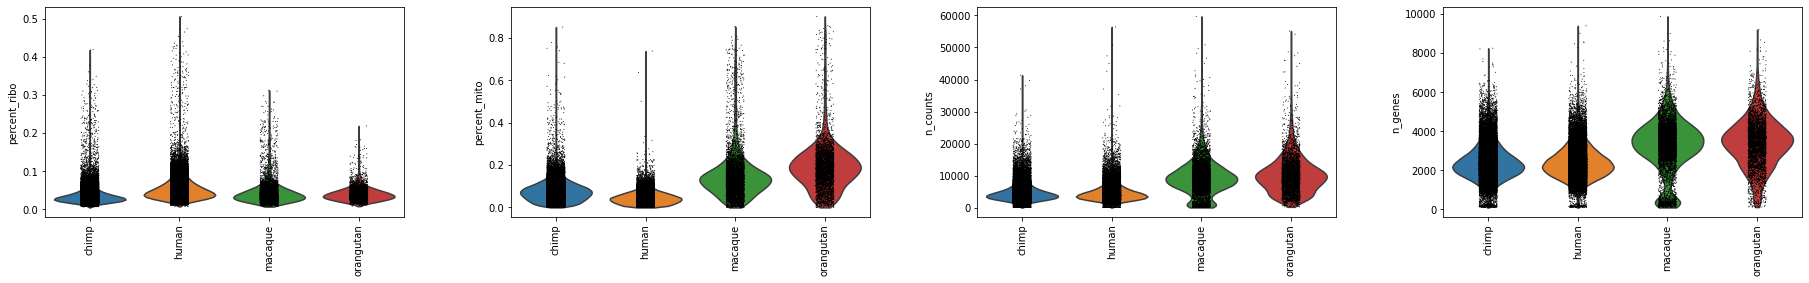

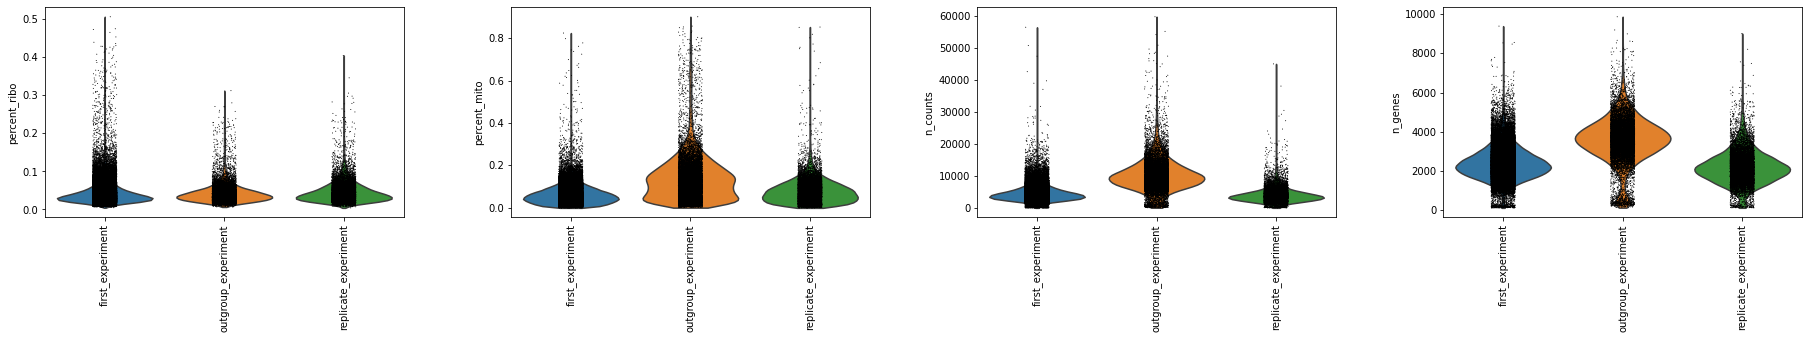

before QC filtering:
AnnData object with n_obs × n_vars = 83608 × 50242
    obs: 'batch_name', 'demux_type', 'assignment', 'CHIR_conc', 'individual', 'individual_type', 'individual_llr', 'species', 'pool_type', 'experiment', 'lane', 'n_genes', 'percent_mito', 'percent_ribo', 'n_counts'
    var: 'gene_ids-D16_CH2_Chimp', 'feature_types-D16_CH2_Chimp', 'genome-D16_CH2_Chimp', 'gene_ids-D16_CH2_Human', 'feature_types-D16_CH2_Human', 'genome-D16_CH2_Human', 'gene_ids-D16_CH_Chimp', 'feature_types-D16_CH_Chimp', 'genome-D16_CH_Chimp', 'gene_ids-D16_CH_Human', 'feature_types-D16_CH_Human', 'genome-D16_CH_Human', 'gene_ids-D16_M0_5_Chimp', 'feature_types-D16_M0_5_Chimp', 'genome-D16_M0_5_Chimp', 'gene_ids-D16_M0_5_Human', 'feature_types-D16_M0_5_Human', 'genome-D16_M0_5_Human', 'gene_ids-D16_M0_5_Orangutan', 'feature_types-D16_M0_5_Orangutan', 'genome-D16_M0_5_Orangutan', 'gene_ids-D16_M0_5_Rhesus', 'feature_types-D16_M0_5_Rhesus', 'genome-D16_M0_5_Rhesus', 'gene_ids-D16_M2_Chimp', 'feature_t

In [24]:
# Pre-filtering QC plots
sc.pl.violin(adata,groupby='species',keys=['percent_ribo','percent_mito', 'n_counts', 'n_genes'],
             rotation=90, multi_panel=True)

sc.pl.violin(adata,groupby='experiment',keys=['percent_ribo','percent_mito', 'n_counts', 'n_genes'],
             rotation=90, multi_panel=True)

print("before QC filtering:")
print(adata)

In [25]:
# Filter cells and based on mitochondrial fractions
adata._inplace_subset_obs(adata.obs['percent_mito']<.15)
adata._inplace_subset_obs(adata.obs['percent_ribo']<.1)

# Get rid of mito genes
adata._inplace_subset_var(~adata.var.index.isin(mito_genes))

# Filter cells and based on counts
sc.pp.filter_genes(adata,min_cells=10) 
sc.pp.filter_cells(adata,min_counts=1000)
sc.pp.filter_cells(adata,min_genes=500)
sc.pp.filter_cells(adata,max_genes=7500)



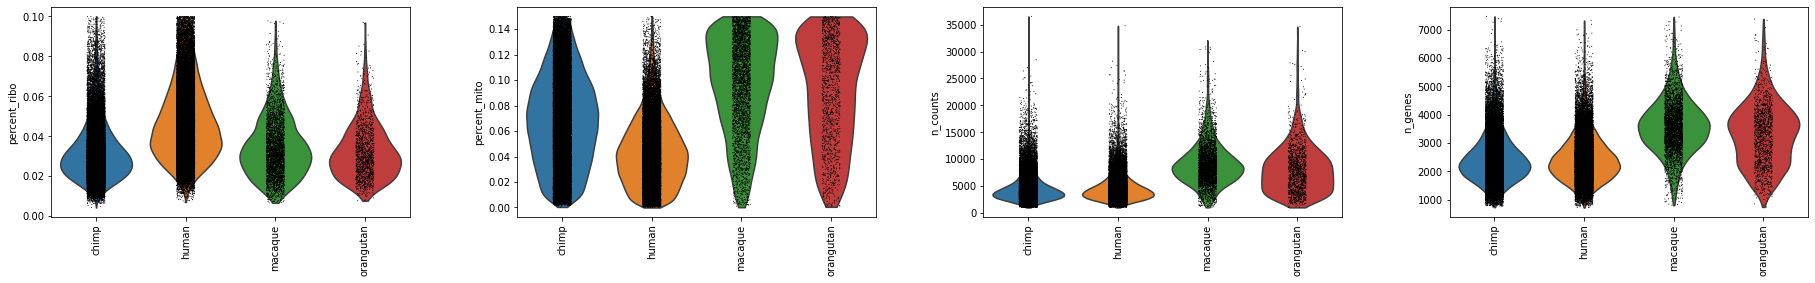

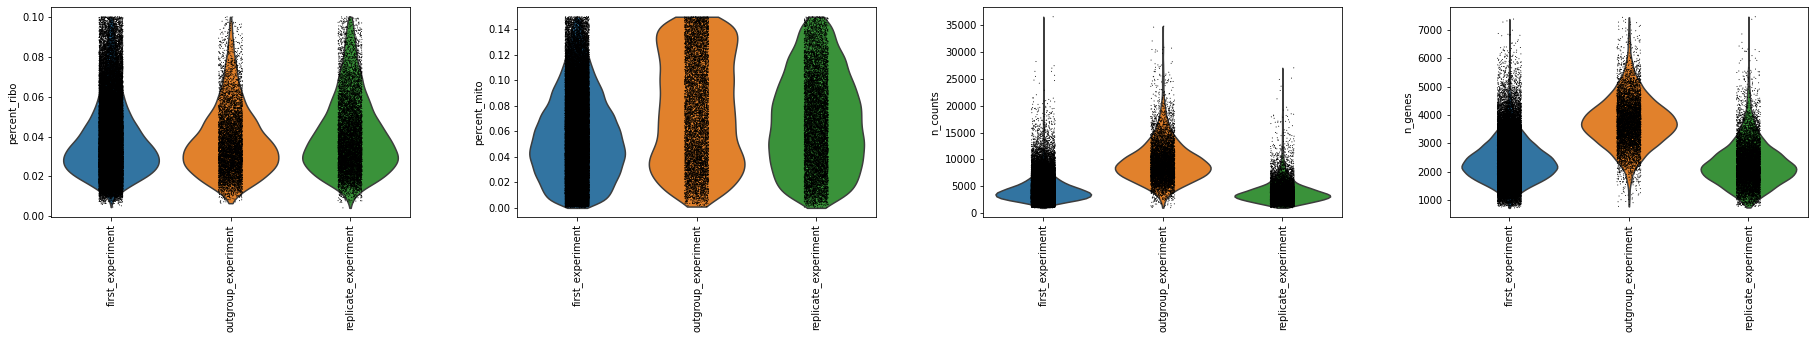

after QC filtering:
AnnData object with n_obs × n_vars = 73077 × 40500
    obs: 'batch_name', 'demux_type', 'assignment', 'CHIR_conc', 'individual', 'individual_type', 'individual_llr', 'species', 'pool_type', 'experiment', 'lane', 'n_genes', 'percent_mito', 'percent_ribo', 'n_counts'
    var: 'gene_ids-D16_CH2_Chimp', 'feature_types-D16_CH2_Chimp', 'genome-D16_CH2_Chimp', 'gene_ids-D16_CH2_Human', 'feature_types-D16_CH2_Human', 'genome-D16_CH2_Human', 'gene_ids-D16_CH_Chimp', 'feature_types-D16_CH_Chimp', 'genome-D16_CH_Chimp', 'gene_ids-D16_CH_Human', 'feature_types-D16_CH_Human', 'genome-D16_CH_Human', 'gene_ids-D16_M0_5_Chimp', 'feature_types-D16_M0_5_Chimp', 'genome-D16_M0_5_Chimp', 'gene_ids-D16_M0_5_Human', 'feature_types-D16_M0_5_Human', 'genome-D16_M0_5_Human', 'gene_ids-D16_M0_5_Orangutan', 'feature_types-D16_M0_5_Orangutan', 'genome-D16_M0_5_Orangutan', 'gene_ids-D16_M0_5_Rhesus', 'feature_types-D16_M0_5_Rhesus', 'genome-D16_M0_5_Rhesus', 'gene_ids-D16_M2_Chimp', 'feature_ty

In [26]:
# Post-filtering QC plots
sc.pl.violin(adata,groupby='species',keys=['percent_ribo','percent_mito', 'n_counts', 'n_genes'],  rotation=90, multi_panel=True, 
             save='human_QC_metrics_time_point')

sc.pl.violin(adata,groupby='experiment',keys=['percent_ribo','percent_mito', 'n_counts', 'n_genes'],  rotation=90, multi_panel=True, 
             save='human_QC_metrics_time_point')

print("after QC filtering:")
print(adata)

/Users/saranolbrant/opt/anaconda3/envs/scanpy-cluster/lib/python3.9/site-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


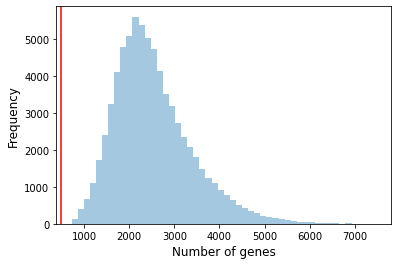

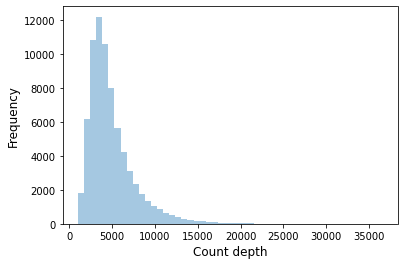

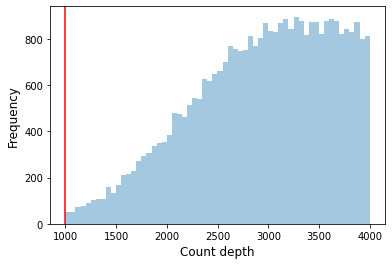

In [27]:
# Histograms of the distrubution of UMI and gene counts

Hist2 = seaborn.distplot(adata.obs['n_genes'], kde=False)
Hist2.set_xlabel("Number of genes", fontsize=12)
Hist2.set_ylabel("Frequency", fontsize=12)
Hist2.axvline(500, 0,1, color='red')

plt.show()

Hist1 = seaborn.distplot(adata.obs['n_counts'], kde=False)
Hist1.set_xlabel("Count depth", fontsize=12)
Hist1.set_ylabel("Frequency", fontsize=12)

plt.show()

Hist3 = seaborn.distplot(adata.obs['n_counts'][adata.obs['n_counts']<4000], kde=False, bins=60)
Hist3.set_xlabel("Count depth", fontsize=12)
Hist3.set_ylabel("Frequency", fontsize=12)
Hist3.axvline(1000, 0,1, color='red')

plt.show()

# Where's the elbow of the count depht distribution?

count_data = adata.obs['n_counts'].copy()
count_data.sort_values(inplace=True, ascending=False)
order =  range(1, len(count_data)+1)
llplot = plt.semilogy(order, count_data, 'b-')
plt.gca().axhline(1000, 0,1, color='red')
plt.xlabel("Barcode rank", fontsize=12)
plt.ylabel("Count depth", fontsize=12)
plt.tick_params(labelsize=12)
plt.plot()

plt.show()

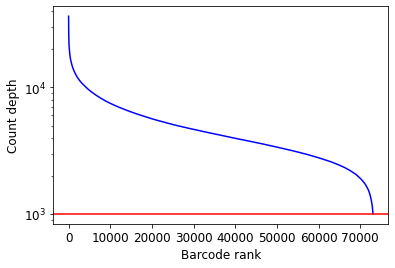

## Normalization, log transformation, scaling

In [29]:
adata.raw=adata

# Total-count normalize (library-size correct) the data matrix 𝐗 to 10,000 reads per cell, so that counts become comparable among cells.
sc.pp.normalize_total(adata, target_sum=1e4)

# Log transform the data
sc.pp.log1p(adata)

In [30]:
# Identify highly-variable genes (HVGs)
sc.pp.highly_variable_genes(adata,n_top_genes=15000,batch_key='batch_name',subset=False)

# Filter highly variable genes
#adata = adata[:, adata.var.highly_variable]

# Regress out effects of total counts per cell and the percentage of mitochondrial genes expressed. 
#sc.pp.regress_out(adata, ['n_counts', 'percent_mito'])

#Scale each gene to unit variance. Clip values exceeding standard deviation 10.
sc.pp.scale(adata, max_value=10)

/Users/saranolbrant/opt/anaconda3/envs/scanpy-cluster/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:475: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  hvg = hvg.append(missing_hvg, ignore_index=True)
/Users/saranolbrant/opt/anaconda3/envs/scanpy-cluster/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:475: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  hvg = hvg.append(missing_hvg, ignore_index=True)
/Users/saranolbrant/opt/anaconda3/envs/scanpy-cluster/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:475: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  hvg = hvg.append(missing_hvg, ignore_index=True)
/Users/saranolbrant/opt/anaconda3/envs/scanpy-

## Principal component analysis

In [31]:
# Principal component analysis - computes PCA coordinates, loadings and variance decomposition
sc.pp.pca(adata,n_comps=50) 

## Computing and embedding the neighborhood graph

In [32]:
# To obtain clusters with merged species identities BBKNN is used as an alternative to scanpy.pp.neighbors(), with both functions creating a neighbour graph
bbknn.bbknn(adata,batch_key='species',n_pcs=50,neighbors_within_batch=3)

# Cluster cells using the Leiden algorithm
sc.tl.leiden(adata,resolution=1.5)

# Embed the neighborhood graph using UMAP
sc.tl.umap(adata,spread=2)

# Project the leiden clusters onto the UMAP
sc.pl.umap(adata,color=['leiden'])

In [33]:
adata.write(Results_file)